In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zona_logistica\esp840_1620_02_2026.csv',sep=',') #for csv files.
unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\don_pollo\Export vbg804.xlsx') #For xls files.
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  371 non-null    str  
 1   Message  371 non-null    str  
 2   Status   371 non-null    str  
dtypes: str(3)
memory usage: 8.8 KB


Odometer

     Odometer in  Odometer en miles
0       45399730       28210.075630
1       45399730       28210.075630
2       45399730       28210.075630
3       45399730       28210.075630
4       45399777       28210.104834
..           ...                ...
366     45551224       28304.209608
367     45551249       28304.225142
368     45551270       28304.238191
369     45551271       28304.238813
370     45551271       28304.238813

[371 rows x 2 columns]


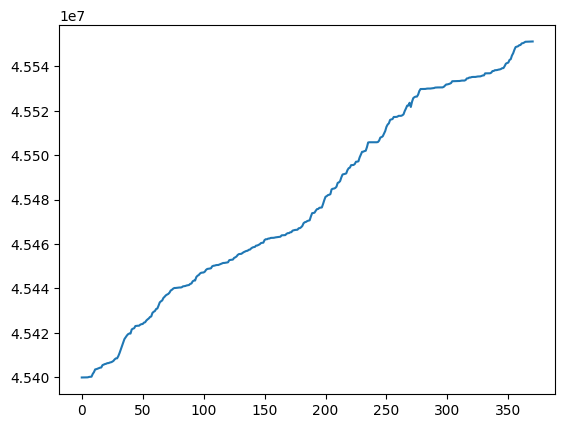

In [3]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

print(unit_odometer)
unit_odometer
plt.plot(x_axis,aux)

Harsh turn

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [4]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

35  ->  2026-07-07 12:09:39.816
35  ->  2026-07-07 12:24:44.840
35  ->  2026-07-07 12:29:55.506
35  ->  2026-07-07 12:34:32.550
35  ->  2026-07-07 12:34:38.922
35  ->  2026-07-07 12:39:10.242
35  ->  2026-07-07 12:42:10.699
35  ->  2026-07-07 12:58:52.973
35  ->  2026-07-07 12:58:54.266
35  ->  2026-07-07 12:58:57.899
35  ->  2026-07-07 12:58:58.324
35  ->  2026-07-07 12:59:02.255
35  ->  2026-07-07 12:59:15.235
35  ->  2026-07-07 13:23:02.293
35  ->  2026-07-07 13:24:39.815
35  ->  2026-07-07 13:29:14.342


Satellite number

In [5]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-07-07 11:31:52.690  ->  0
2026-07-07 11:34:40.770  ->  2
2026-07-07 11:46:49.878  ->  0
2026-07-07 12:27:44.674  ->  3
2026-07-07 12:28:50.589  ->  4
2026-07-07 12:29:48.504  ->  3
2026-07-07 12:29:52.258  ->  3
2026-07-07 12:42:45.455  ->  2
2026-07-07 12:43:20.800  ->  1
2026-07-07 12:58:54.266  ->  3
2026-07-07 13:11:47.560  ->  3
2026-07-07 13:12:03.742  ->  3
2026-07-07 13:20:36.660  ->  2
2026-07-07 13:24:39.815  ->  3
2026-07-07 17:14:24.678  ->  0
2026-07-07 17:14:35.342  ->  0
2026-07-07 19:42:33.543  ->  4
2026-07-07 22:31:16.578  ->  0
2026-07-07 22:53:17.495  ->  4
2026-07-07 23:12:03.997  ->  1
2026-07-07 23:17:30.453  ->  2
Messages with satellite number < 5:  21


Speed

[0, 0, 0, 0, 0, 2, 34, 16, 21, 33, 43, 0, 33, 0, 51, 0, 23, 37, 38, 22, 20, 20, 21, 0, 41, 45, 47, 35, 16, 28, 29, 49, 47, 47, 43, 52, 47, 87, 42, 57, 57, 73, 56, 49, 36, 42, 48, 48, 49, 41, 44, 57, 67, 68, 82, 58, 86, 74, 68, 88, 58, 0, 73, 95, 72, 83, 90, 70, 86, 74, 88, 77, 65, 73, 88, 65, 37, 37, 38, 37, 31, 31, 36, 62, 62, 64, 62, 65, 74, 68, 72, 86, 70, 72, 62, 48, 67, 52, 63, 61, 68, 70, 47, 40, 48, 44, 47, 76, 53, 49, 59, 54, 54, 46, 66, 73, 58, 55, 60, 57, 48, 61, 54, 54, 48, 60, 45, 74, 63, 50, 49, 37, 70, 67, 72, 51, 54, 61, 53, 71, 55, 52, 70, 47, 45, 16, 20, 21, 28, 40, 89, 59, 59, 41, 43, 45, 44, 44, 38, 45, 55, 42, 41, 49, 42, 39, 37, 44, 48, 37, 39, 47, 51, 48, 45, 38, 38, 55, 51, 54, 59, 113, 44, 58, 65, 66, 66, 54, 43, 59, 45, 52, 51, 47, 49, 22, 31, 33, 39, 82, 72, 86, 65, 64, 62, 60, 45, 52, 55, 31, 69, 56, 51, 81, 66, 54, 54, 65, 34, 42, 60, 35, 34, 41, 56, 44, 49, 53, 76, 55, 55, 75, 66, 58, 59, 70, 0, 0, 0, 0, 0, 0, 0, 14, 31, 82, 57, 49, 26, 69, 48, 92, 63, 87, 

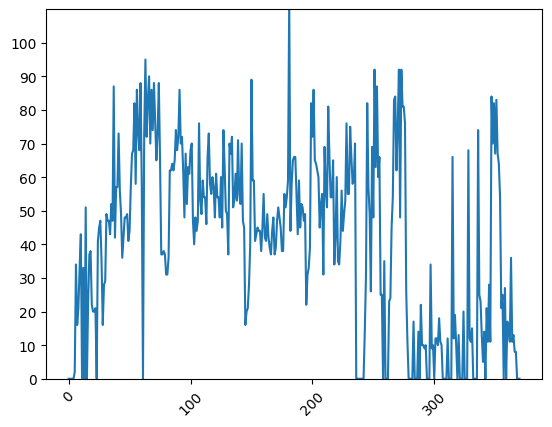

In [ ]:
#Speed reported from Calamp untis is in Km/h, do not confuse, Decoded field pass the Speed in Km/h to mph, but the data is sent to Cloud in Km/H
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)

In [14]:
date=[]

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        aux_s=int(unit.iloc[i,2][56:58],16)
        if aux_s>100:
            print(unit.iloc[i,0],' -> ',aux_s,' -> ',unit.iloc[i,2])
        

2026-07-07 12:59:15.967  ->  113  ->  0x830547644291960101010A251D6A4CF6CCFC3CE2CDD24594E200E771860837030302B5C9AD000036BE00000000


Reporte histórico:
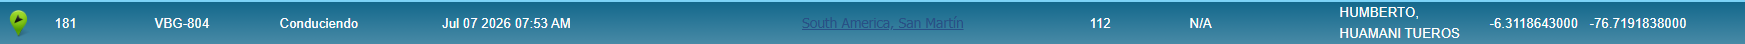

Reporte de velocidad detallado:
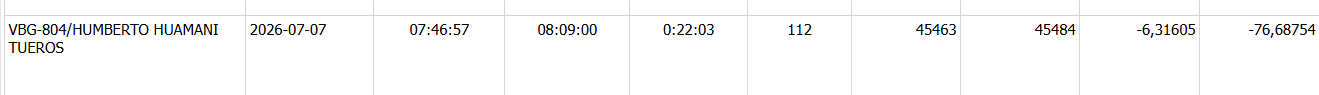

Decodificación en ToolBox:
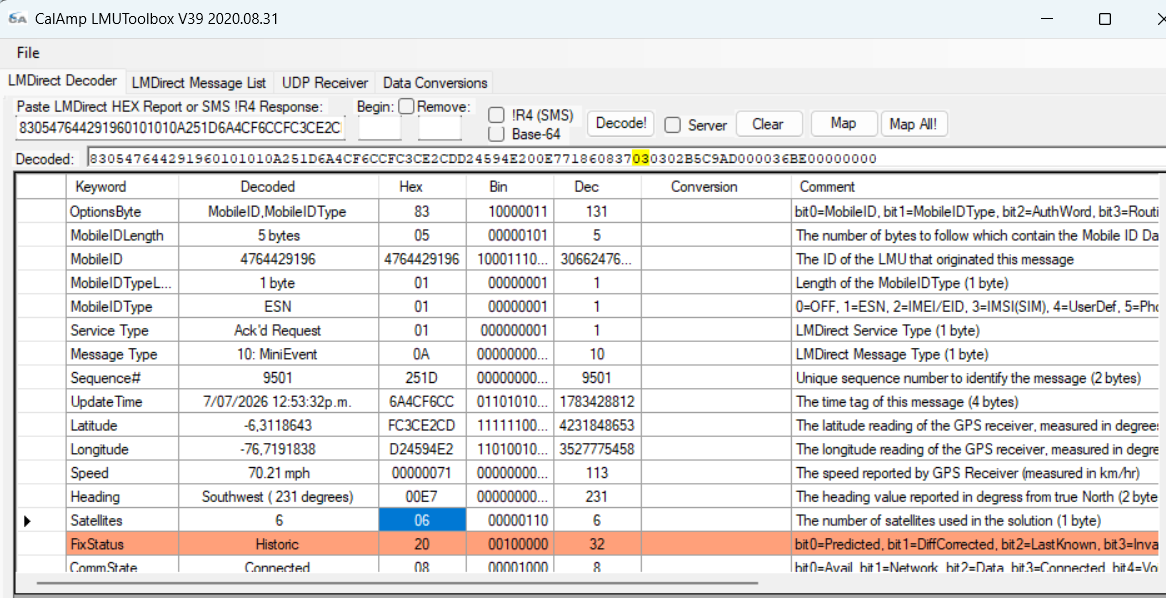